### Research Question
How can machine learning models be leveraged to predict the optimal nightly price for an Airbnb listing—maximizing a host’s revenue by accounting for listing attributes, market trends, and temporal factors?


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [2]:
df = pd.read_csv("listings.csv")
df.shape

(478, 79)

In [3]:
# Select Required Columns
df = df[['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
         'room_type', 'property_type', 'minimum_nights',
         'number_of_reviews', 'review_scores_rating',
         'availability_365', 'instant_bookable']]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 437 non-null    object 
 1   accommodates          478 non-null    int64  
 2   bathrooms             437 non-null    float64
 3   bedrooms              473 non-null    float64
 4   beds                  437 non-null    float64
 5   room_type             478 non-null    object 
 6   property_type         478 non-null    object 
 7   minimum_nights        478 non-null    int64  
 8   number_of_reviews     478 non-null    int64  
 9   review_scores_rating  410 non-null    float64
 10  availability_365      478 non-null    int64  
 11  instant_bookable      478 non-null    object 
dtypes: float64(4), int64(4), object(4)
memory usage: 44.9+ KB


In [5]:
# Checking missing values
df.isnull().sum()

price                   41
accommodates             0
bathrooms               41
bedrooms                 5
beds                    41
room_type                0
property_type            0
minimum_nights           0
number_of_reviews        0
review_scores_rating    68
availability_365         0
instant_bookable         0
dtype: int64

### Handle Missing Values

In [6]:
df['price'] = df['price'].replace('[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['price'] = df['price'].fillna(df['price'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

df.isnull().sum()

price                   0
accommodates            0
bathrooms               0
bedrooms                0
beds                    0
room_type               0
property_type           0
minimum_nights          0
number_of_reviews       0
review_scores_rating    0
availability_365        0
instant_bookable        0
dtype: int64

### Define Features & target variable

In [8]:
X = df.drop('price', axis=1)
y = df['price']

print(X.shape)
print(y.shape)

(478, 11)
(478,)


In [9]:
X = pd.get_dummies(X, drop_first=True)

### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(382, 30)
(96, 30)


### Feature Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Model

In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[ 64.60525246 116.57273979  97.20222004  95.2337777   83.98654468
  37.866137    48.73433225 112.40914992 130.47804024  53.94794842
  81.49504625  54.16910671 143.12730824 115.37035335 196.76468669
  64.60525246  67.68268819 193.08920771  19.80353774  76.70147953
 116.81273938 489.29447887 113.10485925  71.09489399  94.05806755
  66.11448484  28.03292452  74.70548382  67.6069176   97.22345169
 129.16081307 112.22736873  53.10110023  75.59490885 169.8503681
  97.6246552   70.42077219 265.50388782  77.01771364 118.81856824
  72.47666762  64.21597641 130.41875751 130.91561255 124.00560769
  63.45566951  54.91531418 104.82375777  78.56776058 142.1237509
  72.90576405  72.87163211  86.06435341  65.3615825  236.68126892
 194.50948803 108.91066705 113.22327422  67.92167164  53.10840475
  77.12898763  83.29464392 190.35726863  77.44220695  51.62564001
 200.08041135  99.75979271  63.26456121 130.75733674  90.18303426
 171.18366303 238.2179388  167.39509222 140.77560374 125.75553039
  47.0760627

### Model Evaluation

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 30.90628248460259
RMSE: 59.5893842397189
R2 Score: 0.6309096991770091


### Visualization

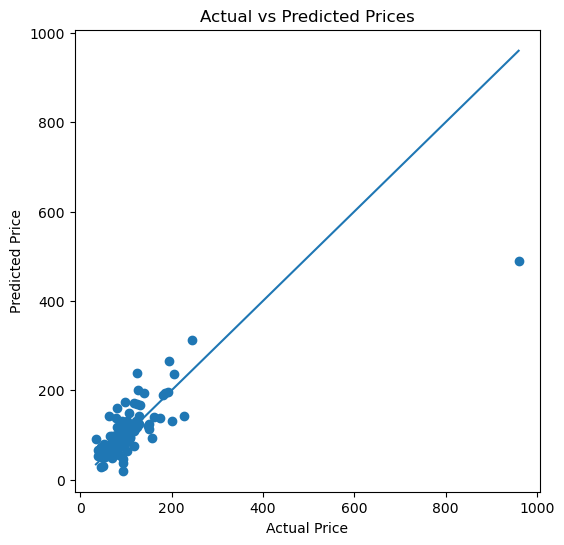

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

The scatter plot indicates that the model predicts most Airbnb prices reasonably close to their actual values.